# RetainIQ — Phase 1.4: Audit Summary & Phase 2 Handoff

## Objective

Consolidate the four-part audit into a formal, reproducible handoff.

This notebook serves as the **Phase 1 validation gate**:

**Raw Data → Audited → Approved for Cleaning**

No transformation is performed here.

## 1. Environment Setup and Data Ingestion

The final notebook reloads the raw source so the summary can be executed independently.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Project convention:
# RetainIQ/
# ├── data/
# │   └── raw/
# │       └── telco.csv
# └── phase_01_data_audit/
#     └── notebooks/
#
# From this notebook, the raw dataset is two levels up from the phase folder.
DATA_PATH = Path("C:\\RetainIQ — AI-Powered Telecom Customer Retention Intelligence Platform\\telco.csv")

# Fallback for running the notebook alongside the uploaded file during development.
if not DATA_PATH.exists():
    DATA_PATH = Path("telco.csv")

df = pd.read_csv(DATA_PATH)

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]:,} columns")

Loaded: 7,043 rows × 50 columns


## 2. Executive Audit Snapshot

The snapshot summarizes the metrics a reviewer should understand before opening the detailed
audit notebooks.

In [3]:
financial_cols = [
    "Monthly Charge",
    "Total Charges",
    "Total Refunds",
    "Total Extra Data Charges",
    "Total Long Distance Charges",
    "Total Revenue",
    "CLTV"
]

snapshot = pd.Series({
    "Customers": len(df),
    "Columns": df.shape[1],
    "Unique Customer IDs": df["Customer ID"].nunique(),
    "Duplicate Customer IDs": int(df["Customer ID"].duplicated().sum()),
    "Missing Customer IDs": int(df["Customer ID"].isna().sum()),
    "Churned Customers": int(df["Churn Label"].eq("Yes").sum()),
    "Stayed Customers": int(df["Churn Label"].eq("No").sum()),
    "Joined Customers": int(df["Customer Status"].eq("Joined").sum()),
    "Overall Churn Rate (%)": round(df["Churn Label"].eq("Yes").mean() * 100, 2),
    "Columns With Missing Values": int(df.isna().any().sum()),
    "Negative Financial Values": int((df[financial_cols] < 0).sum().sum()),
})

snapshot

Customers                     7,043.00
Columns                          50.00
Unique Customer IDs           7,043.00
Duplicate Customer IDs            0.00
Missing Customer IDs              0.00
Churned Customers             1,869.00
Stayed Customers              5,174.00
Joined Customers                454.00
Overall Churn Rate (%)           26.54
Columns With Missing Values       4.00
Negative Financial Values         0.00
dtype: float64

## 3. Target Distribution

The target distribution is recorded because class balance will affect how the churn model is
trained and evaluated in Phase 4.

In [4]:
churn_distribution = (
    df["Churn Label"]
      .value_counts()
      .rename_axis("Churn Label")
      .reset_index(name="Customers")
)

churn_distribution["Percentage"] = (
    churn_distribution["Customers"] / len(df) * 100
).round(2)

churn_distribution

,Churn Label,Customers,Percentage
0,No,5174,73.46
1,Yes,1869,26.54


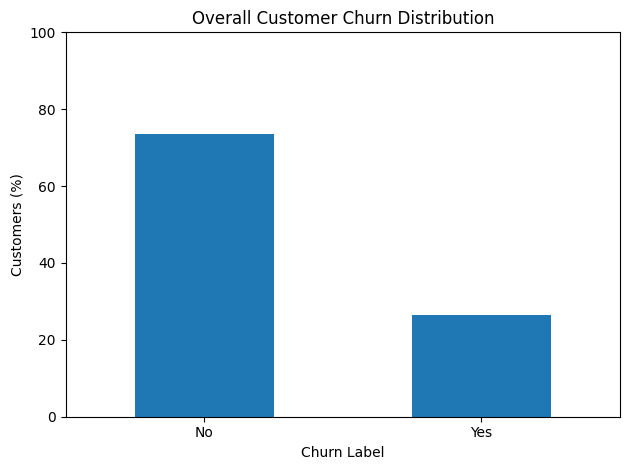

In [5]:
ax = churn_distribution.set_index("Churn Label")["Percentage"].plot(kind="bar")

ax.set_title("Overall Customer Churn Distribution")
ax.set_xlabel("Churn Label")
ax.set_ylabel("Customers (%)")
ax.set_ylim(0, 100)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation

The source contains **1,869 churned customers (26.5%)** and **5,174 non-churned customers
(73.52%)**.

The class distribution is not perfectly balanced, which should be considered when selecting
model metrics in the later statistical/modeling phase.

## 4. Missing-Value Decision Summary

The audit distinguishes nulls by business meaning instead of applying a single blanket imputation
rule.

In [6]:
missing_summary = (
    df.isna()
      .sum()
      .rename("Null Count")
      .to_frame()
)

missing_summary["Null %"] = (
    missing_summary["Null Count"] / len(df) * 100
).round(2)

missing_summary = (
    missing_summary[missing_summary["Null Count"] > 0]
    .sort_values("Null Count", ascending=False)
)

missing_summary

,Null Count,Null %
Churn Reason,5174,73.46
Churn Category,5174,73.46
Offer,3877,55.05
Internet Type,1526,21.67


In [7]:
missing_decisions = pd.DataFrame([
    ["Offer", "Missing values represent an explicit no-offer state.", "Phase 2: No Offer"],
    ["Internet Type", "Missing values represent customers without an internet service type.", "Phase 2: No Internet Service"],
    ["Churn Category", "Null for non-churned customers; structurally not applicable.", "Preserve null"],
    ["Churn Reason", "Null for non-churned customers; structurally not applicable.", "Preserve null"],
], columns=["Field", "Business Interpretation", "Cleaning Decision"])

missing_decisions

,Field,Business Interpretation,Cleaning Decision
0,Offer,Missing values represent an explicit no-offer ...,Phase 2: No Offer
1,Internet Type,Missing values represent customers without an ...,Phase 2: No Internet Service
2,Churn Category,Null for non-churned customers; structurally n...,Preserve null
3,Churn Reason,Null for non-churned customers; structurally n...,Preserve null


## 5. Technical Quality Gate

The following checks convert the audit into executable quality gates.

In [8]:
assert len(df) == 7043
assert df.shape[1] == 50
assert df["Customer ID"].notna().all()
assert df["Customer ID"].is_unique
assert df.duplicated().sum() == 0
assert (df[financial_cols] >= 0).all().all()
assert df[financial_cols].notna().all().all()

print("PASS — Core Phase 1 structural and integrity checks passed.")

PASS — Core Phase 1 structural and integrity checks passed.


## 6. Business Consistency Gate

Customer outcome consistency is also validated before approving the dataset for cleaning.

In [9]:
status_churn = pd.crosstab(df["Customer Status"], df["Churn Label"])

assert status_churn.loc["Churned", "Yes"] == 1869
assert status_churn.loc["Stayed", "No"] == 4720
assert status_churn.loc["Joined", "No"] == 454

print("PASS — Customer Status and Churn Label are internally consistent.")

PASS — Customer Status and Churn Label are internally consistent.


## 7. Final Audit Decision Log

This is the formal list of transformations approved for Phase 2.

In [10]:
final_decision_log = pd.DataFrame([
    {
        "Finding": "Missing Offer",
        "Evidence": f"{df['Offer'].isna().sum():,} rows",
        "Approved Action": 'Replace null with "No Offer"',
        "Reason": "Explicit business state"
    },
    {
        "Finding": "Missing Internet Type",
        "Evidence": f"{df['Internet Type'].isna().sum():,} rows",
        "Approved Action": 'Replace null with "No Internet Service"',
        "Reason": "Explicit non-service state"
    },
    {
        "Finding": "Churn Category",
        "Evidence": f"{df['Churn Category'].isna().sum():,} rows",
        "Approved Action": "Preserve nulls",
        "Reason": "Structurally not applicable to non-churned customers"
    },
    {
        "Finding": "Churn Reason",
        "Evidence": f"{df['Churn Reason'].isna().sum():,} rows",
        "Approved Action": "Preserve nulls",
        "Reason": "Structurally not applicable to non-churned customers"
    },
    {
        "Finding": "Joined customers",
        "Evidence": f"{df['Customer Status'].eq('Joined').sum():,} rows",
        "Approved Action": "Create is_new_customer",
        "Reason": "Exclude new customers from historical churn modeling population"
    },
    {
        "Finding": "String whitespace",
        "Evidence": f"{df.applymap(lambda x: isinstance(x, str) and (x != x.strip())).sum().sum():,} affected cells",
        "Approved Action": "Strip whitespace defensively",
        "Reason": "Standardize categorical values"
    }
])

final_decision_log

C:\Users\Sahil\AppData\Local\Temp\ipykernel_6260\1807437238.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  "Evidence": f"{df.applymap(lambda x: isinstance(x, str) and (x != x.strip())).sum().sum():,} affected cells",


,Finding,Evidence,Approved Action,Reason
0,Missing Offer,"3,877 rows","Replace null with ""No Offer""",Explicit business state
1,Missing Internet Type,"1,526 rows","Replace null with ""No Internet Service""",Explicit non-service state
2,Churn Category,"5,174 rows",Preserve nulls,Structurally not applicable to non-churned cus...
3,Churn Reason,"5,174 rows",Preserve nulls,Structurally not applicable to non-churned cus...
4,Joined customers,454 rows,Create is_new_customer,Exclude new customers from historical churn mo...
5,String whitespace,0 affected cells,Strip whitespace defensively,Standardize categorical values


## 8. Phase 2 Handoff Requirements

The cleaning phase must preserve the following rules:

1. Do not modify the raw source file.
2. Produce a separate `telco_clean` table.
3. Normalize `Offer` to `No Offer` where null.
4. Normalize `Internet Type` to `No Internet Service` where null.
5. Preserve null `Churn Category` and `Churn Reason`.
6. Strip leading/trailing whitespace from string columns.
7. Create `is_new_customer`.
8. Revalidate `Customer ID` uniqueness after transformation.

# 9. Phase 1 Final Conclusion

The raw Telco dataset contains **7,043 customer records and 50 fields** at a validated
one-row-per-customer grain.

The source contains **1,869 churned customers**, producing an overall churn rate of **26.5%**,
alongside **4,720 stayed** customers and **454 joined** customers.

No duplicate customer IDs, missing customer keys, negative audited financial values, or
leading/trailing whitespace issues were detected.

The principal preparation decisions are semantic:

- Standardize missing `Offer` to `No Offer`.
- Standardize missing `Internet Type` to `No Internet Service`.
- Preserve `Churn Category` and `Churn Reason` nulls because they are structurally associated
  with non-churned customers.
- Flag `Joined` customers as `is_new_customer` before churn modeling.
- Apply defensive string trimming during cleaning.

### Phase 1 Status: PASSED

The raw dataset is sufficiently understood and validated to begin **Phase 2 — Data Cleaning &
Transformation**.

## 10. Phase 1 Deliverables

Generated audit artifacts should be stored alongside the notebooks:

- `01_schema_audit.csv`
- `02_missing_values.csv`
- `03_whitespace_audit.csv`
- `04_audit_decision_log.csv`
- `05_audit_snapshot.csv`
